Siamo molto bravi a programmare


In [24]:
import math
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sys

from mlxtend import __version__ as mlxtend_version
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

from collections import defaultdict
from scipy.stats import pearsonr

DATASET_FOLDER = "dataset/"

Poi abbiamo importato

In [25]:
artists = pd.read_csv(DATASET_FOLDER + 'artists.csv', sep=';')
tracks = pd.read_csv(DATASET_FOLDER + 'tracks.csv', sep=',')

print(artists.head())


     id_author           name gender  birth_date birth_place nationality  \
0  ART82291002       99 posse      M         NaN         NaN         NaN   
1  ART53496045  achille lauro      M  1990-07-11      Verona      Italia   
2  ART18853907           alfa      M         NaN         NaN         NaN   
3  ART64265460      anna pepe      F         NaN         NaN         NaN   
4  ART75741740    articolo 31      M         NaN         NaN         NaN   

                            description active_start  active_end province  \
0              gruppo musicale italiano   1991-01-01         NaN      NaN   
1  cantautore e rapper italiano (1990-)   2012-01-01         NaN   Verona   
2                                   NaN          NaN         NaN      NaN   
3                                   NaN          NaN         NaN      NaN   
4      gruppo musicale hip hop italiano   1990-01-01         NaN      NaN   

   region country   latitude  longitude  
0     NaN     NaN        NaN        Na

In [26]:
artists_p = artists.add_prefix("artist_")
tracks_p = tracks.add_prefix("track_")

merged = tracks_p.merge(
    artists_p,
    how="left",
    left_on="track_id_artist",
    right_on="artist_id_author"
)

track_cols = [c for c in merged.columns if c.startswith("track_")]
artist_cols = [c for c in merged.columns if c.startswith("artist_")]

merged.drop(columns=["artist_active_end"], inplace=True)

print(merged.head())

#print(merged["artist_active_end"].unique())

   track_id track_id_artist track_name_artist  \
0  TR934808     ART04205421     Rosa Chemical   
1  TR760029     ART04205421     Rosa Chemical   
2  TR916821     ART04205421     Rosa Chemical   
3  TR480968     ART04205421     Rosa Chemical   
4  TR585039     ART04205421     Rosa Chemical   

                                    track_full_title   track_title  \
0    ​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè)  ​polka 2 :-/   
1         POLKA by Rosa Chemical (Ft. Thelonious B.)         POLKA   
2  ​britney ;-) by Rosa Chemical (Ft. MamboLosco ...  ​britney ;-)   
3                  CEO by Rosa Chemical (Ft. Taxi B)           CEO   
4                LONDRA by Rosa Chemical (Ft. Rkomi)        LONDRA   

  track_featured_artists track_primary_artist track_language  \
0             Ernia, Guè        Rosa Chemical             pl   
1          Thelonious B.        Rosa Chemical             en   
2    MamboLosco, RADICAL        Rosa Chemical             en   
3                 Taxi B    

In [27]:
print('Numero canzoni:', len(merged))
print('Numero canzoni unique:', len(merged.track_id.unique()))

# Drop duplicate track_ids, keeping the first occurrence
merged = merged.drop_duplicates(subset=['track_id'], keep='first')

print('Numero canzoni unique (trimmed):', len(merged.track_id.unique()))
print('Numero artisti:', len(merged.artist_id_author.unique()))

Numero canzoni: 11166
Numero canzoni unique: 11093
Numero canzoni unique (trimmed): 11093
Numero artisti: 104


In [28]:
print(merged.info())

<class 'pandas.core.frame.DataFrame'>
Index: 11093 entries, 0 to 11165
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   track_id                    11093 non-null  object 
 1   track_id_artist             11093 non-null  object 
 2   track_name_artist           11093 non-null  object 
 3   track_full_title            11093 non-null  object 
 4   track_title                 11093 non-null  object 
 5   track_featured_artists      3489 non-null   object 
 6   track_primary_artist        11093 non-null  object 
 7   track_language              10989 non-null  object 
 8   track_album                 9587 non-null   object 
 9   track_stats_pageviews       4610 non-null   float64
 10  track_swear_IT              11093 non-null  int64  
 11  track_swear_EN              11093 non-null  int64  
 12  track_swear_IT_words        11093 non-null  object 
 13  track_swear_EN_words        11093 no

In [29]:
for i in merged.columns:
    n= merged[i].isnull().sum()
    print(f"{i}: {n} null")


track_id: 0 null
track_id_artist: 0 null
track_name_artist: 0 null
track_full_title: 0 null
track_title: 0 null
track_featured_artists: 7604 null
track_primary_artist: 0 null
track_language: 104 null
track_album: 1506 null
track_stats_pageviews: 6483 null
track_swear_IT: 0 null
track_swear_EN: 0 null
track_swear_IT_words: 0 null
track_swear_EN_words: 0 null
track_year: 400 null
track_month: 1192 null
track_day: 1317 null
track_n_sentences: 76 null
track_n_tokens: 76 null
track_tokens_per_sent: 76 null
track_char_per_tok: 76 null
track_lexical_density: 76 null
track_avg_token_per_clause: 76 null
track_bpm: 64 null
track_centroid: 64 null
track_rolloff: 64 null
track_flux: 64 null
track_rms: 64 null
track_zcr: 64 null
track_flatness: 64 null
track_spectral_complexity: 64 null
track_pitch: 64 null
track_loudness: 64 null
track_album_name: 78 null
track_album_release_date: 78 null
track_album_type: 78 null
track_disc_number: 78 null
track_track_number: 78 null
track_duration_ms: 78 null
tr

In [30]:
duplicated_tracks= len(merged) - len(merged.track_id.unique())
print('Numero canzoni duplicate:', duplicated_tracks)

Numero canzoni duplicate: 0


In [31]:
unique= []
for _, row in merged.iterrows():
    name_artist = str(row["track_name_artist"]).lower()
    artist_name = str(row["artist_name"]).lower()
    primary_artist = str(row["track_primary_artist"]).lower()
    triple = (name_artist, artist_name, primary_artist)

    if name_artist != artist_name or name_artist != primary_artist or artist_name != primary_artist:
        if triple not in unique:
            unique.append(triple)
print(unique)

[('guè', 'guè pequeno', 'guè'), ('chadia', 'chadia rodriguez', 'chadia'), ('’o zulù', 'o zulù', '’o zulù'), ('m¥ss keta', 'miss keta', 'm¥ss keta'), ('dargen d’amico', 'dargen d_amico', 'dargen d’amico'), ('mr.rain', 'mr. rain', 'mr.rain'), ('highsnob', 'mike24', 'highsnob'), ('anna', 'anna pepe', 'anna'), ('samuel costa', 'samuel heron', 'samuel costa'), ('joey (ita)', 'joey funboy', 'joey (ita)')]


In [32]:
float_cols = merged.select_dtypes(include=['float64','int64']).columns
for col in float_cols:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")
    mean = merged[col].mean()
    std_dev = merged[col].std()
    outliers = merged[col][merged[col].sub(mean).abs() > 5 * std_dev]
    count= len(outliers)
    print(f"{col}: {count} outliers " )

track_stats_pageviews: 28 outliers 
track_swear_IT: 79 outliers 
track_swear_EN: 77 outliers 
track_month: 0 outliers 
track_day: 0 outliers 
track_n_sentences: 18 outliers 
track_n_tokens: 17 outliers 
track_tokens_per_sent: 24 outliers 
track_char_per_tok: 81 outliers 
track_lexical_density: 57 outliers 
track_avg_token_per_clause: 27 outliers 
track_bpm: 1 outliers 
track_centroid: 1 outliers 
track_rolloff: 10 outliers 
track_flux: 5 outliers 
track_rms: 2 outliers 
track_zcr: 9 outliers 
track_flatness: 221 outliers 
track_spectral_complexity: 0 outliers 
track_pitch: 2 outliers 
track_loudness: 3 outliers 
track_disc_number: 171 outliers 
track_track_number: 11 outliers 
track_duration_ms: 25 outliers 
artist_latitude: 0 outliers 
artist_longitude: 0 outliers 


In [33]:
merged["artist_active_start_year"] = (
    pd.to_numeric(merged["artist_active_start"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

In [34]:
# condizione da eliminare: col_a > 10 e col_b == "X"
track_year_num = pd.to_numeric(merged["track_year"], errors="coerce")
active_start_year_num = pd.to_numeric(merged["artist_active_start_year"], errors="coerce")
mask = (track_year_num > active_start_year_num) & (track_year_num < 2027)
merged["track_year"] = track_year_num.where(mask, pd.NA)

In [35]:
merged["track_tot_swear_words"] = merged["track_swear_IT"] + merged["track_swear_EN"]
for col_name in ["track_popularity", "track_stats_pageviews", "track_bpm", "track_duration_ms", 
                 "track_lexical_density", "track_year", "track_loudness", "track_tot_swear_words",
                 "track_centroid"]:
    #print(merged[col_name].dtype)
    merged[col_name] = pd.to_numeric(merged[col_name], errors="coerce")
    #plt.figure()
    #merged[col_name].hist()
    #plt.title(col_name)
    #plt.xlabel(col_name)
    #plt.yscale('log')
    #plt.show()

# Istogramma cumulativo con IT/EN separati (colori diversi)
swear_it = pd.to_numeric(merged["track_swear_IT"], errors="coerce")
swear_en = pd.to_numeric(merged["track_swear_EN"], errors="coerce")
#plt.figure()
#plt.hist([swear_it, swear_en], bins=30, stacked=True, label=["IT", "EN"], alpha=0.8)
#plt.title("Swear words (IT vs EN)")
#plt.xlabel("Swear words")
#plt.ylabel("Count")
#plt.legend()
#plt.show()

In [36]:
merged["track_bumpiness"] = pd.to_numeric(merged["track_spectral_complexity"], errors="coerce") / (
    pd.to_numeric(merged["track_rolloff"], errors="coerce") - pd.to_numeric(merged["track_centroid"], errors="coerce")
)

merged["track_avg_swear_words"] = merged["track_tot_swear_words"] / merged["track_n_tokens"]


merged["artist_birth_year"] = (
    pd.to_numeric(merged["artist_birth_date"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

merged["track_artist_age"]= merged["track_year"] - merged["artist_birth_year"]

merged["track_tokens_per_sec"] = merged["track_n_tokens"] / (merged["track_duration_ms"] / 1000)


Tra rms e loudness teniamo loudness 
tra rolloff, zcr, e centroid teniamo centroid
tra n_sentences e n_token teniamo n_tokens
tra latitude e longitude teniamo latitude
tra swear words IT ed ENG teniamo IT

In [37]:
merged['track_popularity'] = pd.to_numeric(merged['track_popularity'], errors="coerce")
pop = merged['track_popularity'].dropna()
pop = pop[pop > 0]  # log bins need positive values

r'''
bins = np.logspace(np.log10(1), np.log10(1e6), 40)  # 40 log-width bins

plt.figure('1')
plt.hist(pop, bins=bins)
plt.xscale('log')
plt.title('Track Popularity')
plt.xlabel('Track Popularity')
plt.xlim(1, 1e6)
'''


"\nbins = np.logspace(np.log10(1), np.log10(1e6), 40)  # 40 log-width bins\n\nplt.figure('1')\nplt.hist(pop, bins=bins)\nplt.xscale('log')\nplt.title('Track Popularity')\nplt.xlabel('Track Popularity')\nplt.xlim(1, 1e6)\n"

**Discretization strategy (justification)**
- BPM: cut at 90 and 120 BPM, common musicology thresholds for slow/medium/fast tempos.
- Popularity: use 0–30–70–100 to map to low/medium/high on a 0–100 scale.
- Duration: short < 3 min, medium 3–5 min, long > 5 min (typical radio lengths).
- Swear density: compute swear words per minute; split low/high by median to avoid skew from heavy tails.

TASK 3

--Features-- 

Audio: centroid, rolloff, zcr?, pitch

Latidude, Longitude

Textual: tokens per sentence, swear density, lexical density

Engineered: flatness, presumed flatness

Binary: 

In [38]:
#standardization

standardized = pd.DataFrame()
category_list = {}
category_list["audio"] = ["track_centroid", "track_rolloff", "track_pitch"]
category_list["textual"] = ["track_tokens_per_sent", "track_lexical_density", "track_avg_swear_words"]
#category_list["geo"] = ["artist_latitude", "artist_longitude"]
category_list["popularity"] = ["track_popularity", "track_stats_pageviews"]
#to_standardize = ["textual", "audio", "popularity"]
to_standardize = category_list.keys()  # standardize all categories

print('Rows before dropping missing feature values:', len(merged))

feature_cols = [col for cols in category_list.values() for col in cols]
print('Feature columns:', feature_cols)
merged[feature_cols] = merged[feature_cols].apply(pd.to_numeric, errors="coerce")
merged.dropna(subset=feature_cols, inplace=True)

print('Rows after dropping missing feature values:', len(merged))

for cat, cols in category_list.items():
    for col_name in cols:
        if cat in to_standardize:
            standardized[col_name] = (merged[col_name] - merged[col_name].mean()) / merged[col_name].std()
            #print(f"{col_name}: mean={standardized[col_name].mean():.2f}, std={standardized[col_name].std():.2f}")
        else:
            standardized[col_name] = merged[col_name]
    
print('Rows in standardized data:', len(standardized))

#n_plots = 3
#chosen_category = "textual"

Rows before dropping missing feature values: 11093
Feature columns: ['track_centroid', 'track_rolloff', 'track_pitch', 'track_tokens_per_sent', 'track_lexical_density', 'track_avg_swear_words', 'track_popularity', 'track_stats_pageviews']
Rows after dropping missing feature values: 4603
Rows in standardized data: 4603


In [39]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn import metrics

In [40]:
def clusters_kmeans(cluster_data, clusterMIN = 2, clusterMAX = 10, plot = False):
    silhouettes_kmeans = []
    dbs_kmeans = []
    best_silhouette_kmeans = -np.inf
    best_labels_kmeans = None

    #cluster_data = standardized[category_list[category]]
    print('Cluster data shape:', cluster_data.shape)

    for n_clusters in range(clusterMIN, clusterMAX + 1):

        kmeans = KMeans(n_clusters=n_clusters, n_init=10, max_iter=1000)

        kmeans.fit(cluster_data)

        #unique_values, counts = np.unique(kmeans.labels_, return_counts=True)
        #print('Distinct entries count:', len(unique_values))
        #print('Unique values:', unique_values)
        #print('Counts per value:', counts)

        current_silhouette = metrics.silhouette_score(cluster_data, kmeans.labels_) - metrics.davies_bouldin_score(cluster_data, kmeans.labels_)
        
        if current_silhouette > best_silhouette_kmeans and n_clusters > 1:
            best_silhouette_kmeans = current_silhouette
            best_labels_kmeans = kmeans.labels_
            best_n_clusters_kmeans = n_clusters
            best_real_silhouette_kmeans = metrics.silhouette_score(cluster_data, kmeans.labels_)
            best_dbs_kmeans = metrics.davies_bouldin_score(cluster_data, kmeans.labels_)

        if plot == True:
            silhouettes_kmeans.append(metrics.silhouette_score(cluster_data, kmeans.labels_))
            dbs_kmeans.append(metrics.davies_bouldin_score(cluster_data, kmeans.labels_))

        #print('SSE %s' % kmeans.inertia_)
        #print('Silhouette %s' % silhouettes_kmeans)
        #print('Separation %s' % dbs_kmeans)

    if plot == True:
        plt.plot(range(clusterMIN, clusterMAX + 1), silhouettes_kmeans, label='Silhouette', color='blue')
        plt.plot(range(clusterMIN, clusterMAX + 1), dbs_kmeans, label='Davies-Bouldin', color='red')
        plt.xlabel('Number of Clusters')
        plt.ylabel('Scores')
        plt.legend()
        plt.show()

    return best_n_clusters_kmeans, best_labels_kmeans, best_real_silhouette_kmeans, best_dbs_kmeans

In [41]:
#cluster_data = standardized[[col for cols in category_list.values() for col in cols]]

In [42]:
def clusters_dbscan(cluster_data, iterations = 10, eps_lims = [0.1, 10], plot = False, verbose = False, min_noise = 0.):
    best_silhouette = -np.inf
    best_n_clusters = -1
    best_eps = -1
    best_labels_dbscan = np.full(cluster_data.shape[0], -1)
    silhouettes_dbscan = []
    dbs_dbscan = []

    for eps, min_samples in zip(np.linspace(eps_lims[0], eps_lims[1], num=iterations), np.full(iterations, 10)):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)

        dbscan.fit(cluster_data)

        unique_values, counts = np.unique(dbscan.labels_, return_counts=True)
        if verbose == True:
            print('Distinct entries count:', len(unique_values))
            print('Unique values:', unique_values)
            print('Counts per value:', counts)
            print('Eps:', eps)

        #print('SSE %s' % dbscan.inertia_)
        if len(set(dbscan.labels_)) > 1 and len(set(dbscan.labels_)) < len(cluster_data) and counts[0] >= cluster_data.shape[0] * min_noise:
            current_silhouette = metrics.silhouette_score(cluster_data, dbscan.labels_) - metrics.davies_bouldin_score(cluster_data, dbscan.labels_)
            if current_silhouette > best_silhouette:
                best_silhouette = current_silhouette
                best_n_clusters = len(set(dbscan.labels_))
                best_eps = eps
                best_labels_dbscan = dbscan.labels_
                best_dbs = metrics.davies_bouldin_score(cluster_data, dbscan.labels_)

                if verbose == True:
                    print('New best silhouette: ', current_silhouette + best_dbs)
                    print('Separation: ', best_dbs)

        if plot == True:
                silhouettes_dbscan.append(metrics.silhouette_score(cluster_data, dbscan.labels_))
                dbs_dbscan.append(metrics.davies_bouldin_score(cluster_data, dbscan.labels_))

    if plot == True:
        plt.plot(range(eps_lims[0], eps_lims[1] + 1), silhouettes_dbscan, label='Silhouette', color='blue')
        plt.plot(range(eps_lims[0], eps_lims[1] + 1), dbs_dbscan, label='Davies-Bouldin', color='red')
        plt.xlabel('Eps')
        plt.ylabel('Scores')
        plt.legend()
        plt.show()

    if verbose == True:
        print(f"Best DBSCAN silhouette: {best_silhouette} with {best_n_clusters} clusters and eps: {best_eps}")
    
    return best_n_clusters, best_labels_dbscan, best_eps, best_silhouette, best_dbs


In [43]:
def plot_clusters(category_list = category_list, dataset = standardized, fit_labels = [], label = "insert label"):
    for category1 in range(len(category_list)):
        for category2 in range(category1 + 1, len(category_list)):
            plt.figure()
            plt.scatter(dataset[category_list[category1]], dataset[category_list[category2]], c = fit_labels, alpha=1, marker='.', s=10)
            plt.xlabel(category_list[category1])
            plt.ylabel(category_list[category2])
            plt.title(label)
            plt.show()

In [44]:
from sklearn.decomposition import PCA

def pca_plot(dataset = standardized, category_list = [], fit_labels = [], n_components = 2, plot_label = "PCA Plot"):
    pca = PCA(n_components = n_components)
    reduced_data = pca.fit_transform(dataset[category_list])
    
    plt.figure()
    plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=fit_labels, alpha=1, marker='.', s=10)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(plot_label)
    plt.show()
    

Clustering category: audio
Cluster data shape: (4603, 3)
Distinct entries count: 1
Unique values: [-1]
Counts per value: [4603]
Eps: 0.1
Distinct entries count: 13
Unique values: [-1  0  1  2  3  4  5  6  7  8  9 10 11]
Counts per value: [2202 2253   17   16   15   10   13   10   20   18   10   11    8]
Eps: 0.2
New best silhouette:  -0.4380791011539995
Separation:  1.9121607058571635
Distinct entries count: 3
Unique values: [-1  0  1]
Counts per value: [ 745 3849    9]
Eps: 0.3
Distinct entries count: 3
Unique values: [-1  0  1]
Counts per value: [ 323 4270   10]
Eps: 0.4
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [ 160 4443]
Eps: 0.5
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  97 4506]
Eps: 0.6
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  40 4563]
Eps: 0.7
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  25 4578]
Eps: 0.7999999999999999
Distinct entries count: 2
Unique values: [-1  0]
Coun

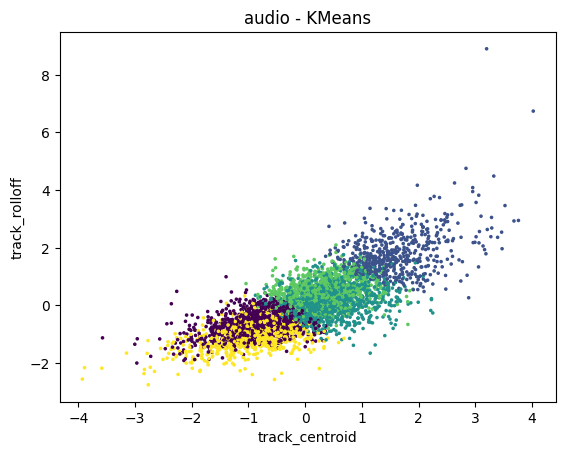

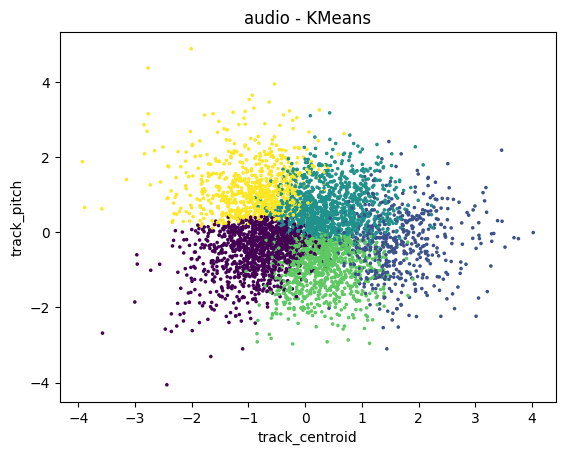

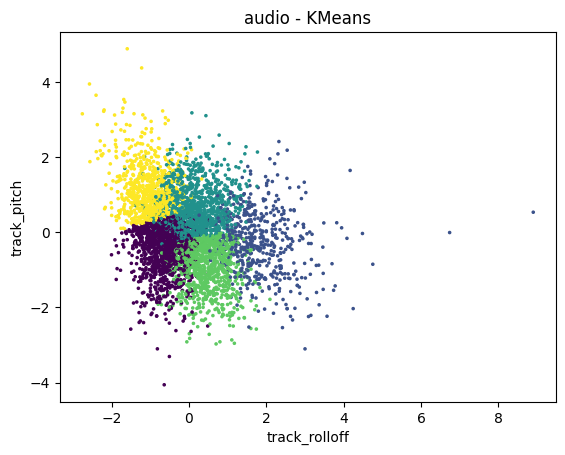

KMeans - Best silhouette: 0.2766065297045868, Best Davies-Bouldin: 1.0125033827191938, Clusters: 5


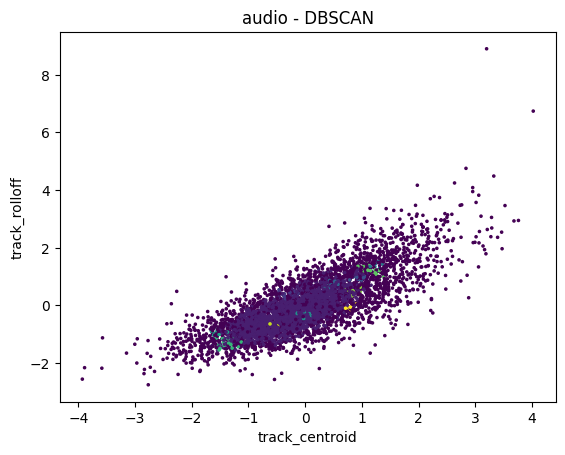

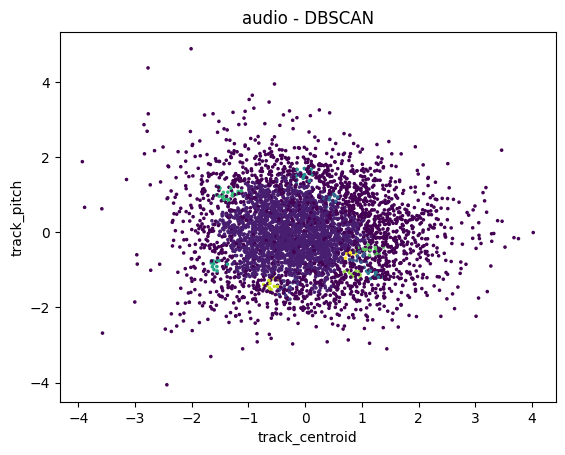

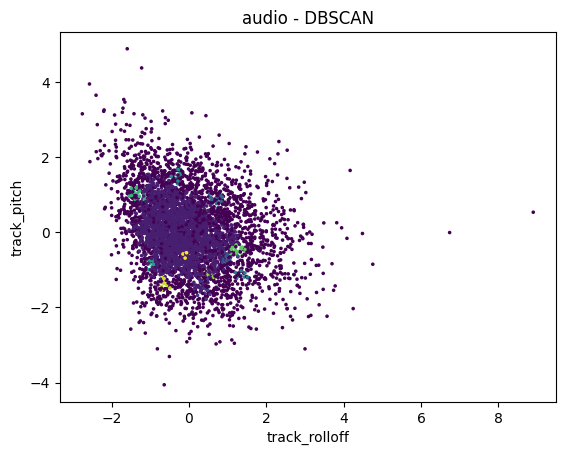

DBSCAN - Best silhouette: -2.350239807011163, Best Davies-Bouldin: 1.9121607058571635, Clusters: 13, Eps: 0.2


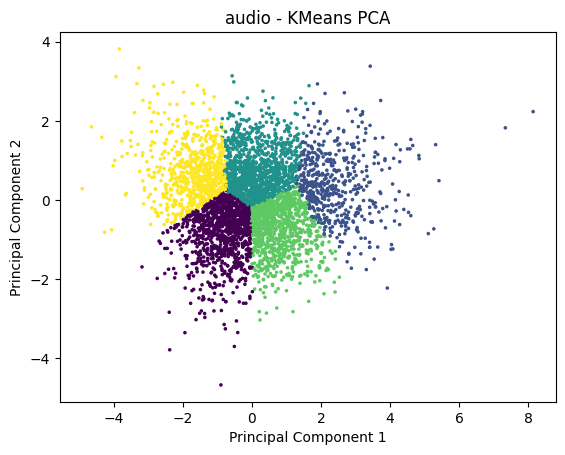

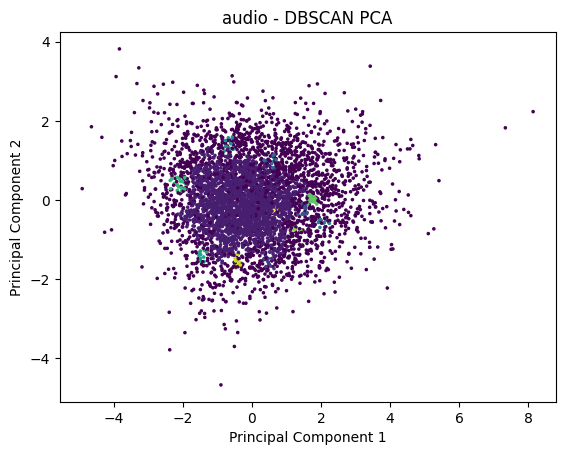

Clustering category: textual
Cluster data shape: (4603, 3)
Distinct entries count: 16
Unique values: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Counts per value: [4364   32   26   17   15   14   15   11   36   13   11   12   10   10
    7   10]
Eps: 0.1
New best silhouette:  -0.45835863276983657
Separation:  1.7836664773449376
Distinct entries count: 8
Unique values: [-1  0  1  2  3  4  5  6]
Counts per value: [1942 2585   15   12   11   20   10    8]
Eps: 0.2
Distinct entries count: 5
Unique values: [-1  0  1  2  3]
Counts per value: [ 944 3632    9    8   10]
Eps: 0.3
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [ 510 4093]
Eps: 0.4
New best silhouette:  0.44557515737093745
Separation:  2.478419755071704
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [ 313 4290]
Eps: 0.5
New best silhouette:  0.5072666954142568
Separation:  2.16198462928286
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [ 193 4410]
Eps: 0.6
New best

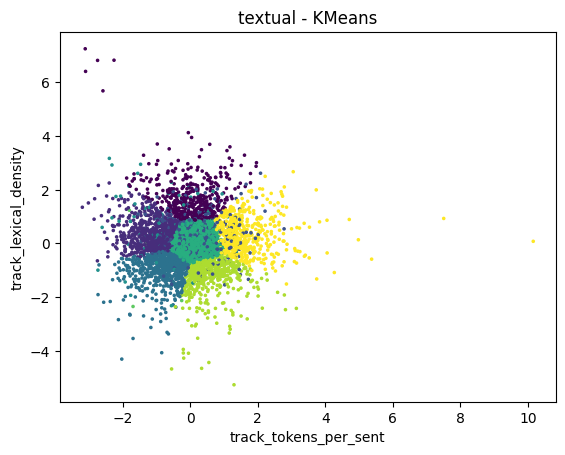

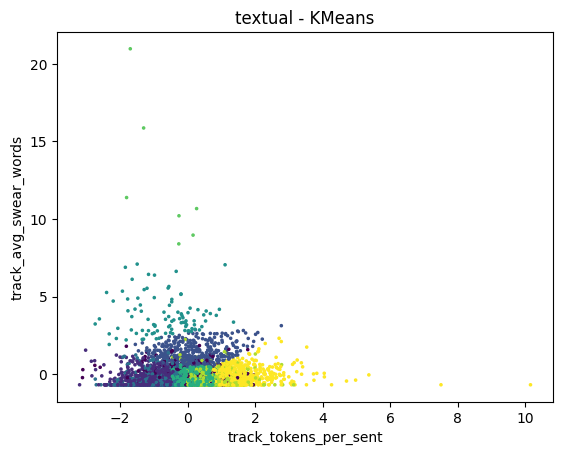

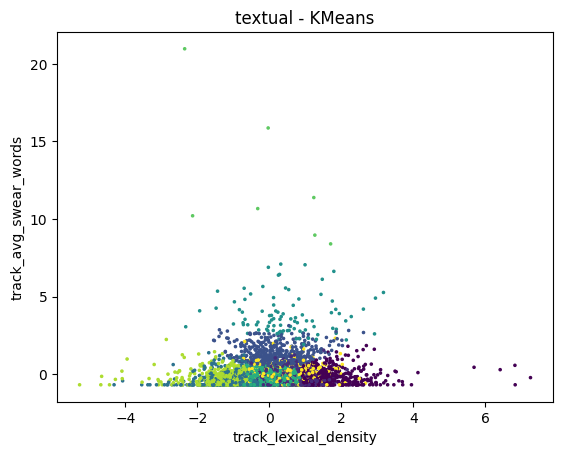

KMeans - Best silhouette: 0.24220085135022523, Best Davies-Bouldin: 0.9913626629106278, Clusters: 9


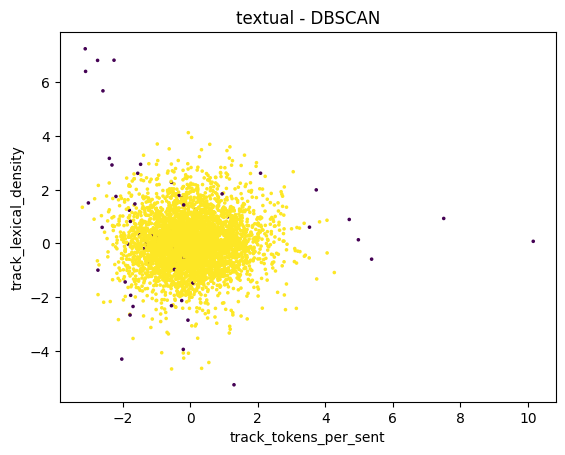

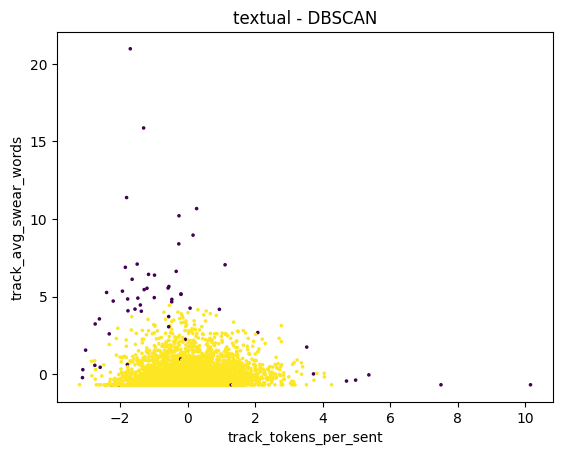

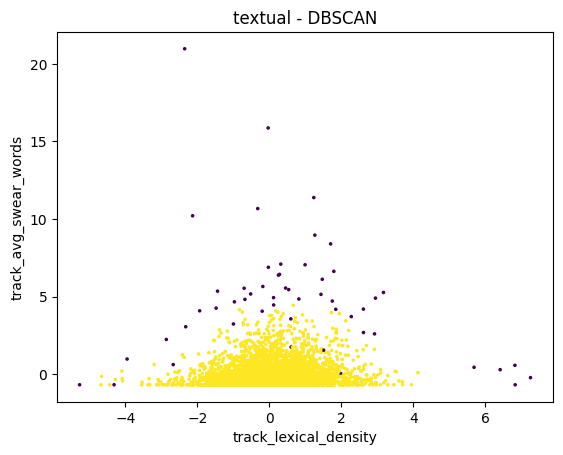

DBSCAN - Best silhouette: -0.6059101037369546, Best Davies-Bouldin: 1.2939742047088383, Clusters: 2, Eps: 0.9999999999999999


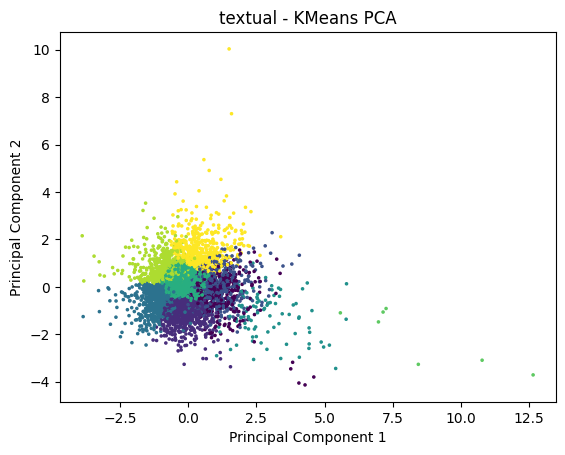

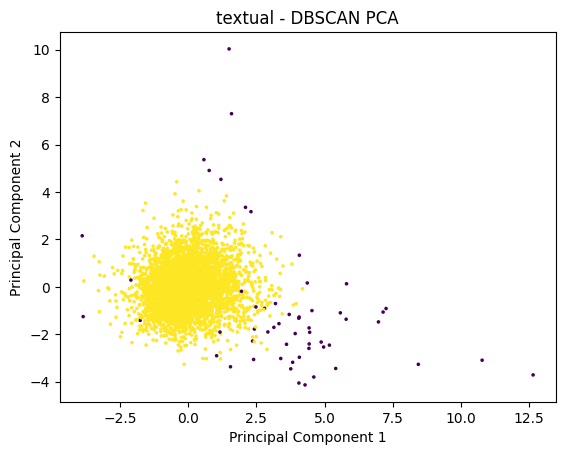

Clustering category: popularity
Cluster data shape: (4603, 2)
Distinct entries count: 8
Unique values: [-1  0  1  2  3  4  5  6]
Counts per value: [ 592 3917   32   17    5   18   16    6]
Eps: 0.1
New best silhouette:  -0.24008626433950364
Separation:  1.6498213079321806
Distinct entries count: 4
Unique values: [-1  0  1  2]
Counts per value: [ 206 4382    7    8]
Eps: 0.2
Distinct entries count: 3
Unique values: [-1  0  1]
Counts per value: [ 115 4477   11]
Eps: 0.3
New best silhouette:  0.5698548551015299
Separation:  2.3475750761653855
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  72 4531]
Eps: 0.4
New best silhouette:  0.7208365330476576
Separation:  0.8115511104631523
Distinct entries count: 3
Unique values: [-1  0  1]
Counts per value: [  36 4552   15]
Eps: 0.5
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  28 4575]
Eps: 0.6
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  17 4586]
Eps: 0.7
Distinct entries coun

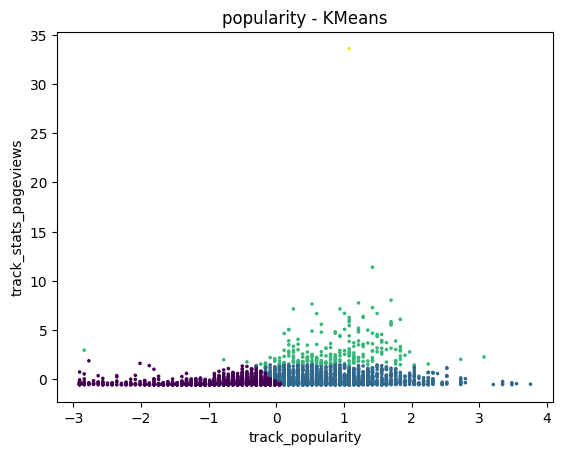

KMeans - Best silhouette: 0.45825979030105596, Best Davies-Bouldin: 0.5810472938604015, Clusters: 4


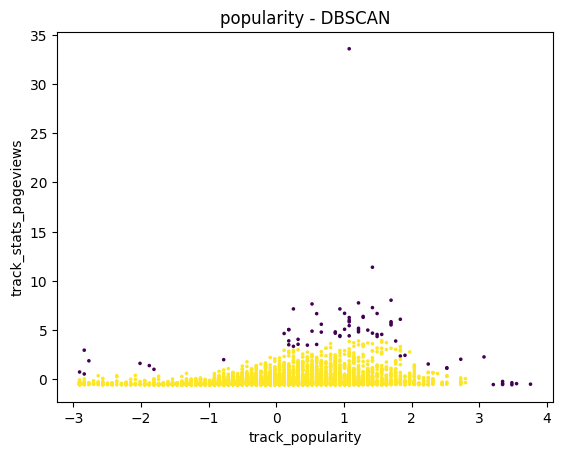

DBSCAN - Best silhouette: -0.09071457741549471, Best Davies-Bouldin: 0.8115511104631523, Clusters: 2, Eps: 0.4


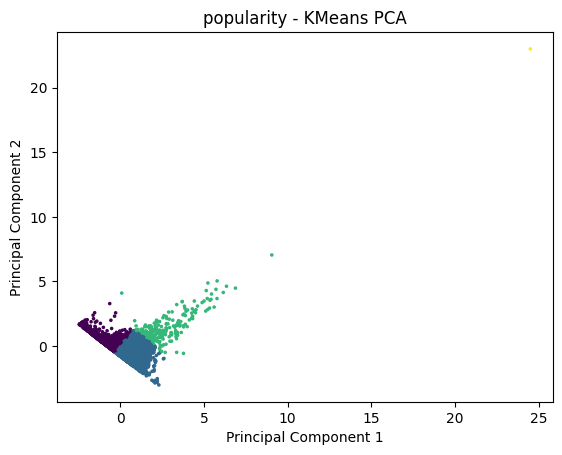

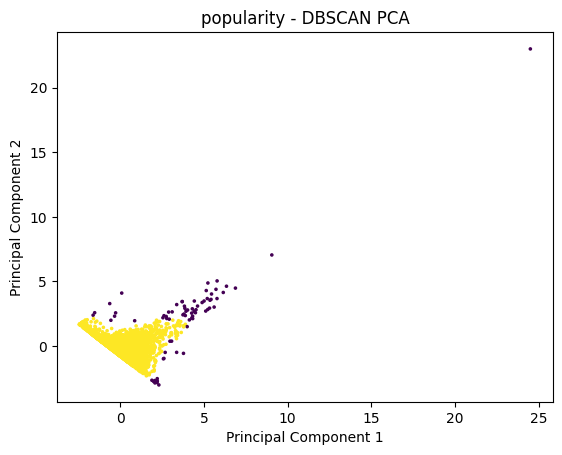

In [ ]:
#cluster (coherent)

for category, cols in category_list.items():
    cluster_data = standardized[cols]
    print(f"Clustering category: {category}")

    best_n_clusters_kmeans, best_labels_kmeans, best_silhouette_kmeans, best_dbs_kmeans = clusters_kmeans(cluster_data)
    
    best_n_clusters_dbscan, best_labels_dbscan, best_eps, best_silhouette_dbscan, best_dbs_dbscan = clusters_dbscan(cluster_data, eps_lims=[0.1, 3], iterations=30, verbose = True, min_noise = 0.01)
    
    plot_clusters(category_list=cols, dataset=standardized, fit_labels=best_labels_kmeans, label=f"{category} - KMeans")
    print(f"KMeans - Best silhouette: {best_silhouette_kmeans}, Best Davies-Bouldin: {best_dbs_kmeans}, Clusters: {best_n_clusters_kmeans}")

    plot_clusters(category_list=cols, dataset=standardized, fit_labels=best_labels_dbscan, label=f"{category} - DBSCAN")
    print(f"DBSCAN - Best silhouette: {best_silhouette_dbscan}, Best Davies-Bouldin: {best_dbs_dbscan}, Clusters: {best_n_clusters_dbscan}, Eps: {best_eps}")

    pca_plot(dataset=standardized, category_list=cols, fit_labels=best_labels_kmeans, plot_label=f"{category} - KMeans PCA")
    pca_plot(dataset=standardized, category_list=cols, fit_labels=best_labels_dbscan, plot_label=f"{category} - DBSCAN PCA")
    

Cluster data shape: (4603, 8)


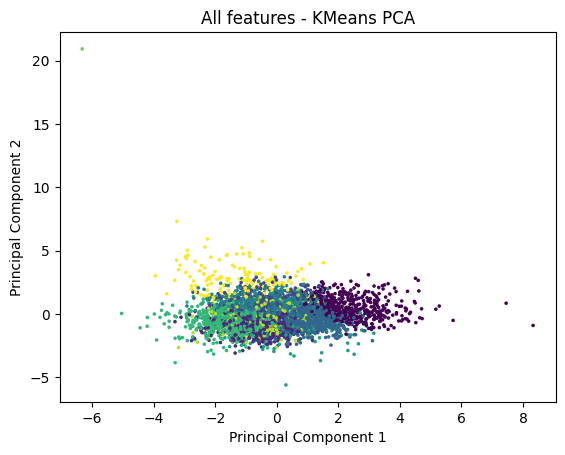

KMeans - Best silhouette: 0.11795895072632757, Best Davies-Bouldin: 1.5076460246378727, Clusters: 10


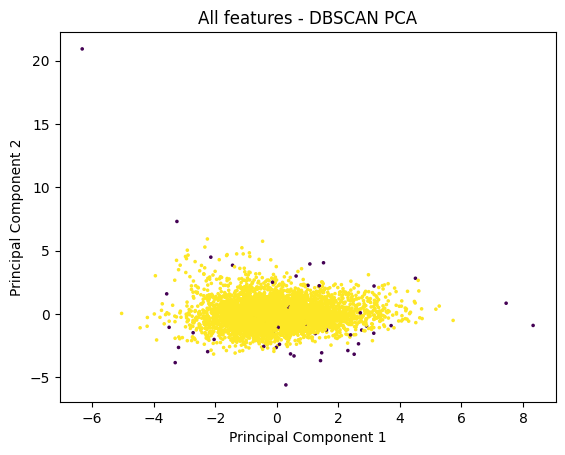

DBSCAN - Best silhouette: -1.740263749604104, Best Davies-Bouldin: 2.3151685897433705, Clusters: 2, Eps: 2.4


In [48]:
#clustering and PCA (incoherent)

best_n_clusters_kmeans, best_labels_kmeans, best_silhouette_kmeans, best_dbs_kmeans = clusters_kmeans(standardized[[item for keys in category_list.keys() for item in category_list[keys]]])

best_n_clusters_dbscan, best_labels_dbscan, best_eps, best_silhouette_dbscan, best_dbs_dbscan = clusters_dbscan(standardized[[item for keys in category_list.keys() for item in category_list[keys]]], eps_lims=[0.1, 3], iterations=30, verbose = False, min_noise = 0.01)

pca_plot(dataset=standardized, category_list=[item for keys in category_list.keys() for item in category_list[keys]], fit_labels=best_labels_kmeans, plot_label="All features - KMeans PCA")
print(f"KMeans - Best silhouette: {best_silhouette_kmeans}, Best Davies-Bouldin: {best_dbs_kmeans}, Clusters: {best_n_clusters_kmeans}")

pca_plot(dataset=standardized, category_list=[item for keys in category_list.keys() for item in category_list[keys]], fit_labels=best_labels_dbscan, plot_label="All features - DBSCAN PCA")
print(f"DBSCAN - Best silhouette: {best_silhouette_dbscan}, Best Davies-Bouldin: {best_dbs_dbscan}, Clusters: {best_n_clusters_dbscan}, Eps: {best_eps}")